In [47]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# read file
# df = pd.read_csv("/Users/akshayswaminathan/vf_copilot/evals/data/raw/de_id_conversations_to_audit.csv")
df = pd.read_csv("/Users/akshayswaminathan/Downloads/sampled_message_level_data_20250913.csv")


In [48]:

# ['counsellor', 'counsellor_xp', 'unique_conversation_id', 'msg_sequence', 'sender', 'advanced_prompt', 'bleu_scores', 'deid_message', 'deid_initial_ai_suggestion']

# filter for sender == "Counselor"
counselor_messages = df[df['sender'] == 'Counselor']


counselor_messages['message_length'] = counselor_messages['message'].apply(lambda x: len(str(x)))

counselor_messages['suggestion_length'] = counselor_messages['ai_suggestion'].apply(lambda x: len(str(x)))

# if suggestion_length is <5, set it to NaN
counselor_messages.loc[counselor_messages['suggestion_length'] < 5, 'suggestion_length'] = None

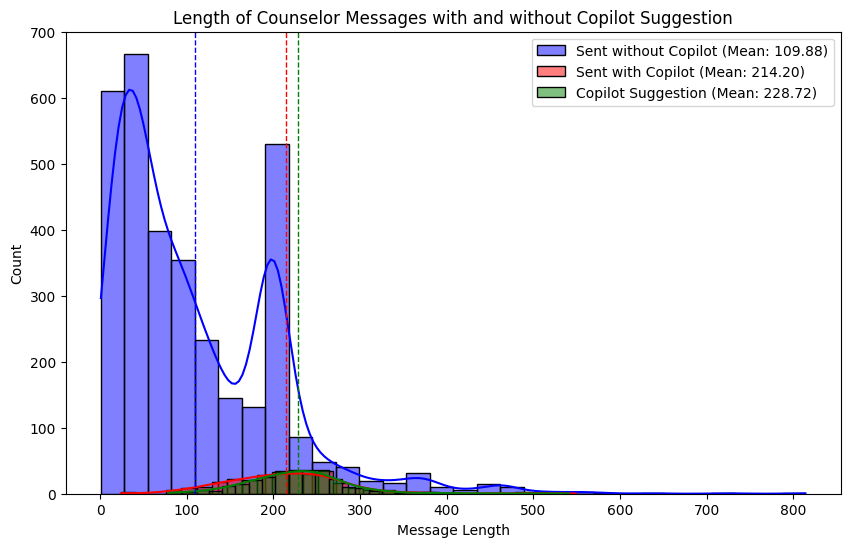

In [6]:
# Define colors
colors = {'no_copilot': 'blue', 'with_copilot': 'red', 'suggestion': 'green'}

# Calculate means
mean_no_copilot = counselor_messages[counselor_messages['ai_suggestion'].isnull()]['message_length'].mean()
mean_with_copilot = counselor_messages[counselor_messages['ai_suggestion'].notnull()]['message_length'].mean()
mean_suggestion = counselor_messages['suggestion_length'].mean()

# Create the plot
plt.figure(figsize=(10, 6))

sns.histplot(
    counselor_messages[counselor_messages['ai_suggestion'].isnull()]['message_length'], 
    bins=30, color=colors['no_copilot'], label=f'Sent without Copilot (Mean: {mean_no_copilot:.2f})', kde=True
)
sns.histplot(
    counselor_messages[counselor_messages['ai_suggestion'].notnull()]['message_length'], 
    bins=30, color=colors['with_copilot'], label=f'Sent with Copilot (Mean: {mean_with_copilot:.2f})', kde=True
)
sns.histplot(
    counselor_messages['suggestion_length'], 
    bins=30, color=colors['suggestion'], label=f'Copilot Suggestion (Mean: {mean_suggestion:.2f})', kde=True
)

# Add vertical mean lines
plt.axvline(mean_no_copilot, color=colors['no_copilot'], linestyle='dashed', linewidth=1)
plt.axvline(mean_with_copilot, color=colors['with_copilot'], linestyle='dashed', linewidth=1)
plt.axvline(mean_suggestion, color=colors['suggestion'], linestyle='dashed', linewidth=1)

# Add labels and title
plt.title('Length of Counselor Messages with and without Copilot Suggestion')
plt.xlabel('Message Length')
plt.ylabel('Count')

# Add the legend
plt.legend()

# Show the plot
plt.show()

In [10]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import AutoTokenizer, AutoModel
from sklearn.cluster import KMeans
from umap import UMAP


In [11]:

# Load transformer model and tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

# Ensure model is in evaluation mode
model.eval()

# Function to generate embeddings
def get_transformer_embedding(text):
    tokens = tokenizer(text, return_tensors="pt", truncation=True, padding=True)
    with torch.no_grad():
        output = model(**tokens)
    return output.last_hidden_state.mean(dim=1).squeeze().numpy()


In [47]:

# Extract messages and lengths
messages = counselor_messages['deid_message'].astype(str).tolist()
message_lengths = counselor_messages['message_length'].values

# Compute embeddings for all messages
transformer_embeddings = np.array([get_transformer_embedding(msg) for msg in messages])


In [26]:
from openai import OpenAI
from tqdm import tqdm
import numpy as np
import pandas as pd
from dotenv import load_dotenv
import os

# Load API key from .env file
load_dotenv("/Users/akshayswaminathan/vf_copilot/.env")
api_key = os.getenv("OPENAI_API_KEY")

# Initialize OpenAI client
client = OpenAI(api_key=api_key)

# Function to get OpenAI embeddings
def get_openai_embedding(text):
    response = client.embeddings.create(
        input=text,
        model="text-embedding-3-small"
    )
    return response.data[0].embedding

# Extract messages
messages = counselor_messages['deid_message'].astype(str).tolist()

# Batch process embeddings
openai_embeddings = np.array([get_openai_embedding(msg) for msg in tqdm(messages, desc="Generating OpenAI Embeddings")])


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Generating OpenAI Embeddings: 100%|██████████| 999/999 [04:45<00:00,  3.50it/s]


In [48]:
embeddings = transformer_embeddings

In [37]:

# Reduce dimensionality for visualization
umap = UMAP(n_components=2, random_state=41)
reduced_embeddings = umap.fit_transform(embeddings)


/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

In [49]:
from sklearn.manifold import TSNE
# Reduce dimensionality using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
reduced_embeddings = tsne.fit_transform(embeddings)

In [50]:

# Perform clustering
num_clusters = 3  # Adjust based on data
kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(reduced_embeddings)


In [51]:

# Create a DataFrame for visualization
vis_df = pd.DataFrame(reduced_embeddings, columns=['x', 'y'])
vis_df['Cluster'] = cluster_labels
vis_df['Message Length'] = message_lengths


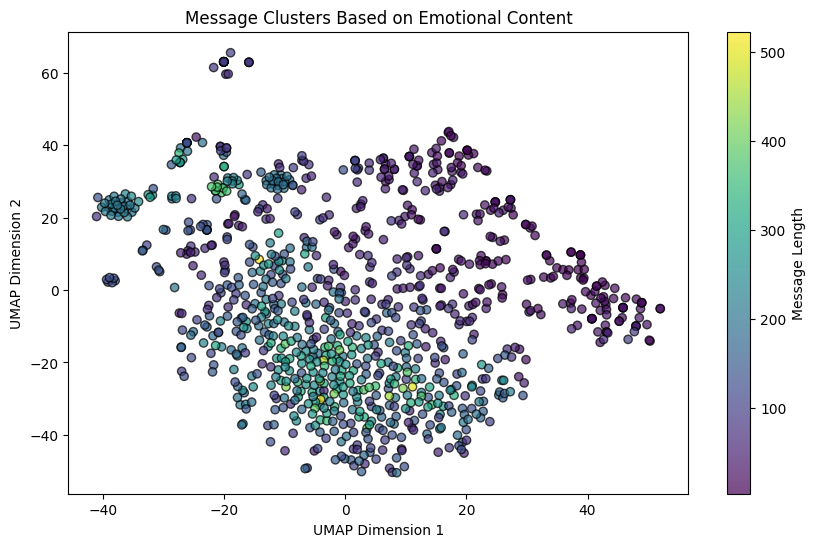

In [52]:

# Plot clusters with message length as color
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    vis_df['x'], vis_df['y'], 
    c=vis_df['Message Length'], cmap='viridis', alpha=0.7, edgecolors='k'
)
plt.colorbar(scatter, label='Message Length')
plt.title('Message Clusters Based on Emotional Content')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

# Show the plot
plt.show()


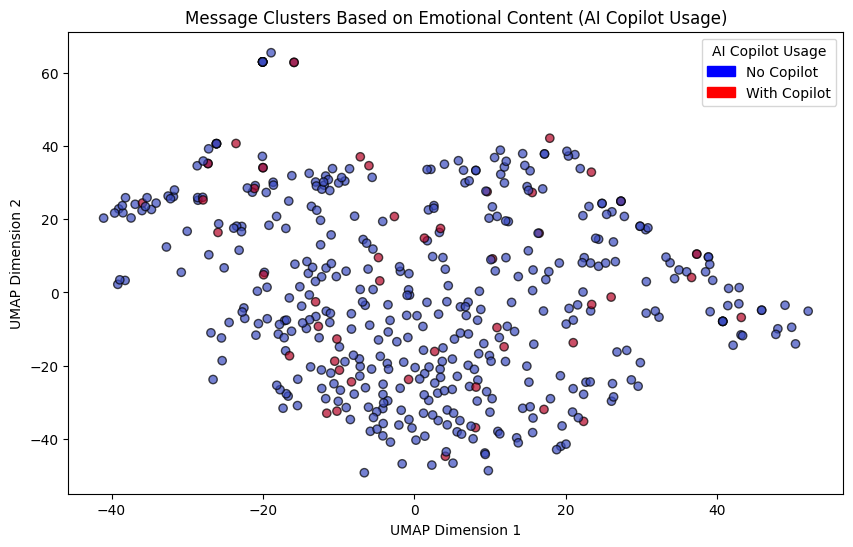

In [53]:
# Add AI copilot usage to the visualization DataFrame
vis_df['AI Copilot Used'] = counselor_messages['deid_initial_ai_suggestion'].notnull()

# Plot clusters with AI copilot usage as color
plt.figure(figsize=(10, 6))

# Scatter plot with color based on AI Copilot usage
scatter = plt.scatter(
    vis_df['x'], vis_df['y'], 
    c=vis_df['AI Copilot Used'].map({True: 1, False: 0}),  # Convert boolean to numeric
    cmap='coolwarm', alpha=0.7, edgecolors='k'
)

# Add legend manually
import matplotlib.patches as mpatches
legend_patches = [
    mpatches.Patch(color='blue', label='No Copilot'),
    mpatches.Patch(color='red', label='With Copilot')
]
plt.legend(handles=legend_patches, title="AI Copilot Usage")

# Plot aesthetics
plt.title('Message Clusters Based on Emotional Content (AI Copilot Usage)')
plt.xlabel('UMAP Dimension 1')
plt.ylabel('UMAP Dimension 2')

# Show the plot
plt.show()


In [3]:
from __future__ import annotations
from openai import OpenAI
from pydantic import BaseModel, Field
from dotenv import load_dotenv
from tqdm import tqdm
import pandas as pd
import numpy as np
import os, json, time, pathlib
from typing import Optional

# -----------------------------
# Setup
# -----------------------------
load_dotenv("/Users/akshayswaminathan/vf_copilot/.env")
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Your messages DataFrame
# counselor_messages = pd.DataFrame({"message": [...]})

# -----------------------------
# Structured output via Pydantic
# -----------------------------
class MessageRating(BaseModel):
    rating: int = Field(..., description="1=logistical, 2=between, 3=therapeutic")

# Convert Pydantic model -> JSON Schema for Responses structured output
JSON_SCHEMA = {
    "name": "MessageRating",
    "schema": MessageRating.model_json_schema(),  # requires pydantic>=2
}

SYSTEM_PROMPT = """You analyze counselor messages from a crisis hotline.

Scale:
1: Purely logistical message — minimal therapeutic content.
2: In between 1 and 3.
3: Therapeutic content — exploring, advising, rapport, coping, emotional depth.

Return the rating only.

Examples:

Rating 1:
- “It seems like you are caught up at the moment. I will be marking this chat as closed for now, but feel free to contact us again via chats or call on <PHI>, and we would be there to support you.”
- “Hello, I am <PHI>, your counsellor for today.”

Rating 2:
- “I understand that you are in need of support, and I want to assure you that we're here to help. Please wait while I send over the resources.”
- “How long has this been going on for you?”

Rating 3:
- “Thank you for sharing your details <PHI>, I see that you have been trying to work on your habits of watching porn and masturbation for two years now, and I understand that it has not been easy for you.”
- “Those sound like good options! If you want, I could assist you with some resources that could help you with working through your urges by focusing in the present, as well as some alternate activities that you could do when you are feeling low.”
"""

MODEL = "gpt-4.1"  # or another Responses-capable model

# -----------------------------
# Create JSONL batch input
# -----------------------------
def write_batch_jsonl(messages: list[str], jsonl_path: str) -> None:
    """
    Each line targets the /v1/responses endpoint with structured output.
    We pass your Pydantic-derived JSON schema so outputs are guaranteed JSON.
    """
    with open(jsonl_path, "w", encoding="utf-8") as f:
        for i, m in enumerate(messages):
            body = {
                "model": MODEL,
                "input": [
                    {"role": "system", "content": SYSTEM_PROMPT},
                    {"role": "user", "content": f'Message: "{m}"'}
                ],
                "response_format": {
                    "type": "json_schema",
                    "json_schema": JSON_SCHEMA
                },
            }
            line = {
                "custom_id": f"msg-{i}",
                "method": "POST",
                "url": "/v1/responses",
                "body": body,
            }
            f.write(json.dumps(line, ensure_ascii=False) + "\n")

    try:
        response = client.chat.completions.create(
            model="gpt-4.1",
            messages=[{"role": "system", "content": "You are a helpful assistant."},
                      {"role": "user", "content": prompt}]
        )
        rating = int(response.choices[0].message.content.strip())
        return rating
    except Exception as e:
        print(f"Error processing message: {e}")
        return None  # Handle API errors gracefully

def poll_batch(batch_id: str, poll_interval: float = 5.0, progress: bool = True):
    """
    Polls until status in {'completed','failed','expired','cancelled'}.
    Returns the final batch object.
    """
    if progress:
        print(f"Polling batch {batch_id} ...")
    while True:
        b = client.batches.retrieve(batch_id)
        s = b.status
        if progress:
            print(f"status: {s}")
        if s in {"completed", "failed", "expired", "cancelled"}:
            return b
        time.sleep(poll_interval)

def download_file(file_id: str, out_path: str) -> None:
    content = client.files.content(file_id)
    with open(out_path, "wb") as f:
        f.write(content.read())

# -----------------------------
# Parse batch outputs
# -----------------------------
def parse_batch_outputs(jsonl_path: str, n_items: int) -> list[Optional[int]]:
    """
    The output JSONL contains one line per successful request.
    We load the model's JSON (structured) and parse into MessageRating.
    """
    ratings: list[Optional[int]] = [None] * n_items
    with open(jsonl_path, "r", encoding="utf-8") as f:
        for line in f:
            rec = json.loads(line)
            # Expected shape (schematic):
            # {
            #   "custom_id": "msg-0",
            #   "response": {
            #       "status_code": 200,
            #       "body": {
            #           "id": "...",
            #           "output": [...],
            #           "output_text": "...",   (may exist)
            #           ...
            #       }
            #   },
            #   "error": null
            # }
            custom_id = rec.get("custom_id")
            idx = int(custom_id.split("-")[1]) if custom_id else None

            if rec.get("error"):
                continue

            body = rec.get("response", {}).get("body", {})
            # Extract the concatenated text if present; otherwise stitch from blocks
            text = body.get("output_text")
            if not text:
                # Fallback to first text block if needed
                try:
                    text = body["output"][0]["content"][0]["text"]
                except Exception:
                    text = None

            if not text:
                continue

            # The model was constrained by json_schema; parse into Pydantic
            try:
                obj = MessageRating.model_validate_json(text)
                ratings[idx] = obj.rating if obj.rating in (1, 2, 3) else None
            except Exception:
                ratings[idx] = None
    return ratings

# -----------------------------
# Orchestrate everything
# -----------------------------
def run_batch_rating(counselor_messages: pd.DataFrame,
                     messages_col: str = "message",
                     temp_dir: str = "./.batch",
                     completion_window: str = "24h") -> pd.DataFrame:
    os.makedirs(temp_dir, exist_ok=True)
    msgs = counselor_messages[messages_col].astype(str).tolist()
    input_jsonl = os.path.join(temp_dir, "request.jsonl")

    # 1) Write input JSONL
    write_batch_jsonl(msgs, input_jsonl)

    # 2) Upload + create batch
    batch = submit_batch(input_jsonl, completion_window=completion_window)

    # 3) Poll to terminal state
    batch = poll_batch(batch.id, poll_interval=5.0, progress=True)

    if batch.status != "completed":
        print(f"Batch finished with status: {batch.status}")
        return counselor_messages.assign(rating_1to3=None)

    # 4) Download output JSONL
    out_jsonl = os.path.join(temp_dir, "output.jsonl")
    download_file(batch.output_file_id, out_jsonl)

    # 5) Parse outputs -> ratings
    ratings = parse_batch_outputs(out_jsonl, n_items=len(msgs))

    # 6) Merge back to DataFrame
    df = counselor_messages.copy()
    df["rating_1to3"] = ratings
    return df

# -----------------------------
# Example usage
# -----------------------------
# result_df = run_batch_rating(counselor_messages)
# result_df.to_csv("counselor_messages_with_ratings.csv", index=False)


In [4]:
result_df = run_batch_rating(counselor_messages.head(100))
# result_df.to_csv("counselor_messages_with_ratings.csv", index=False)

Polling batch batch_68d9ba1b98f48190bbac5cb4cbe358b7 ...
status: validating
status: validating
status: validating
status: validating
status: validating
status: validating
status: validating
status: validating
status: validating
status: validating
status: validating
status: validating
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_progress
status: in_prog

KeyboardInterrupt: 

In [ ]:

# Apply classification in batches with progress bar
# print the current iteration

messages = counselor_messages["message"].astype(str).tolist()

ratings = []
for i, message in tqdm(enumerate(messages), total=len(messages), desc="Classifying Messages"):
    rating = classify_message(message)
    ratings.append(rating)
    if i % 10 == 0:  # Print every 10 iterations
        print(f"Processed {i} messages")


Processed 0 messages


Processed 10 messages


Processed 20 messages


Processed 30 messages


Processed 40 messages


...

Processed 960 messages


Processed 970 messages


Processed 980 messages


Processed 990 messages


Classifying Messages: 100%|██████████| 999/999 [06:55<00:00,  2.40it/s]


In [58]:
import pandas as pd
import re
import json

gpt_output_path = "/Users/akshayswaminathan/vf_copilot/evals/data/llm_inference/extracted_completions/message_classification_092825_.csv"
message_classification_df = pd.read_csv(gpt_output_path)

def extract_json_from_text(input_string):
    try:
        match = re.search(r'\{.*\}', input_string, re.DOTALL)
        if not match:
            raise ValueError("No JSON-like content found.")
        json_string = match.group(0)
        json_data = json.loads(json_string)
        return json_data
    except:
        return {"result": "Unable to parse JSON",
                "original_response": input_string}
        
message_classification_df['message_rating'] = message_classification_df['llm_eval_json'].apply(extract_json_from_text)
message_classification_df['message_rating'] = message_classification_df['message_rating'].apply(lambda x: x['rating'] if 'rating' in x else 1)

# join with counselor_messages
counselor_messages_with_ratings_df = message_classification_df.merge(counselor_messages, on='uid', how='left')
counselor_messages_with_ratings_df.head()


,uid,prompt_template_name,llm_eval_json,file_name,input_file_name,message_rating,id,DateInserted,event,message_sender_id,...,bert_precision,bert_recall,bert_f1,time_diff,new_conversation,conversation_id,msg_sequence,msg_sequence_overall,message_length,suggestion_length
0,4321732,message_classification,"```json\n{\n ""rating"": 1\n}\n```",final_merged_gpt-4.1_max500_20250928_163229,NaN,1,4321732,2025-05-03 05:38:23.870,conversation.operator.replied,3.571300e+16,...,NaN,NaN,NaN,0 days 00:00:10.267000,False,2832,1.0,6,95,NaN
1,5868875,message_classification,"```json\n{\n ""rating"": 1\n}\n```",final_merged_gpt-4.1_max500_20250928_163229,NaN,1,5868875,2025-08-24 12:08:45.583,conversation.operator.replied,3.571300e+16,...,NaN,NaN,NaN,0 days 00:00:09.203000,False,86748,8.0,25,6,NaN
2,5078156,message_classification,"```json\n{\n ""rating"": 1\n}\n```",final_merged_gpt-4.1_max500_20250928_163229,NaN,1,5078156,2025-06-30 14:41:03.027,conversation.operator.replied,3.571300e+16,...,NaN,NaN,NaN,0 days 00:05:15.817000,False,81224,5.0,12,14,NaN
3,4188846,message_classification,"```json\n{\n ""rating"": 2\n}\n```",final_merged_gpt-4.1_max500_20250928_163229,NaN,2,4188846,2025-04-22 06:41:49.573,conversation.operator.replied,3.571300e+16,...,NaN,NaN,NaN,0 days 00:01:55.296000,False,55837,12.0,29,43,NaN
4,4126167,message_classification,"```json\n{\n ""rating"": 3\n}\n```",final_merged_gpt-4.1_max500_20250928_163229,NaN,3,4126167,2025-04-16 18:43:06.957,conversation.operator.replied,3.571300e+16,...,1.0,1.0,1.0,0 days 00:00:39.487000,False,36389,3.0,20,89,89.0


In [61]:

# # Store results in a DataFrame
# counselor_messages['message_rating'] = ratings

# # Save to CSV (optional)
# counselor_messages.to_csv("counselor_messages_with_ratings.csv", index=False)

# # Display first few results
# counselor_messages[['deid_message', 'message_rating']].head()




In [60]:
# randomly sample 5 examples of each rating, separated by new lines, without truncation
# counselor_messages = pd.read_csv("counselor_messages_with_ratings.csv")

for rating in range(1, 4):
    print(f"Rating {rating} examples:\n")
    examples = counselor_messages_with_ratings_df[counselor_messages_with_ratings_df['message_rating'] == rating]['message'].sample(5, random_state=42).tolist()
    print("\n\n".join(examples))
    print("\n\n\n")

Rating 1 examples:

https://vandrevalafoundation.zohodesk.in/portal/en/kb/articles/how-i-wanted-to-be-treated

I had a lot of pimples on my face

For ease of conversation, would you be okay with sharing your name, age, gender ?

Distraction techniques for Self-Harm

Thank you for your kind words.




Rating 2 examples:

I appreciate

ene though you know that it is not a healthy one for you?

Okay thank you for sharing the details, Sakshi....What can i help you with today?

On scale of 0-10, where 0 is that these thoughts are managable by you and 10 is these thoughts are unbearable  and extremely distressing. What will you rate them?

All this help to balance yourself




Rating 3 examples:

Take care of yourself as well.These are difficult times for you too

I understand he has been keeping you and the family restricted to just the 3 of you'll and I do here you say that he has put all of you at home in the cycle of working and saving and not spend. 
 
I hear you say that he is also ask

In [62]:
# report the  mean length of messages rated 1, 2, and 3, along with the sample size
mean_lengths = counselor_messages_with_ratings_df.groupby('message_rating')['message_length'].agg(['mean', 'count'])
mean_lengths.columns = ['Mean Length', 'Sample Size']
print(mean_lengths)

                Mean Length  Sample Size
message_rating                          
1                114.075747         4119
2                 72.647504         2244
3                169.115205         3637


In [63]:
summary_table = counselor_messages_with_ratings_df.groupby('message_rating').agg(
    n_messages=('message', 'count'),
    prop_ai_suggestion=('ai_suggestion', lambda x: x.notnull().mean()),
    mean_message_length=('message_length', 'mean')
).reset_index()

summary_table

,message_rating,n_messages,prop_ai_suggestion,mean_message_length
0,1,4119,0.000000,114.075747
1,2,2244,0.013815,72.647504
2,3,3637,0.258455,169.115205


In [64]:
counselor_messages_with_ratings_df.message_rating.value_counts(normalize=True)

message_rating
1    0.4119
3    0.3637
2    0.2244
Name: proportion, dtype: float64